# COVID-19 in India - EDA on the first wave

Mini project for Module 1. I'm looking at India's COVID-19 data from the start of the outbreak (Jan 2020) up to early August 2020, and the vaccination numbers from 2021 onwards.

Stuff I want to figure out:
- how fast cases actually grew across the country
- which states got hit the hardest and which barely got touched
- how recovery and death rates differed between states
- whether the lockdown phases show up in the numbers at all
- how the vaccine rollout went once it started

Data sources:
- state-wise daily data from [imdevskp/covid-19-india-data](https://github.com/imdevskp/covid-19-india-data) (`complete.csv`)
- India vaccinations from [Our World in Data](https://github.com/owid/covid-19-data)

Both load directly from GitHub so you don't need to download anything.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 20)

CASES_URL = "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
VACC_URL = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"

# so the y axis shows 1.5L instead of 150000
def lakh(x, pos=None):
    if abs(x) >= 1e5:
        return f"{x/1e5:.1f}L"
    return f"{x:,.0f}"

## Loading the data

In [2]:
raw = pd.read_csv(CASES_URL)
vacc_raw = pd.read_csv(VACC_URL)
print(raw.shape, vacc_raw.shape)
raw.head()

(4692, 10) (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


Checking types and missing values first.

In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4692 entries, 0 to 4691
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       4692 non-null   object 
 1   Name of State / UT         4692 non-null   object 
 2   Latitude                   4692 non-null   float64
 3   Longitude                  4692 non-null   float64
 4   Total Confirmed cases      4692 non-null   float64
 5   Death                      4692 non-null   object 
 6   Cured/Discharged/Migrated  4692 non-null   float64
 7   New cases                  4692 non-null   int64  
 8   New deaths                 4692 non-null   int64  
 9   New recovered              4692 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 366.7+ KB


In [4]:
raw.isna().sum()

Date                         0
Name of State / UT           0
Latitude                     0
Longitude                    0
Total Confirmed cases        0
Death                        0
Cured/Discharged/Migrated    0
New cases                    0
New deaths                   0
New recovered                0
dtype: int64

In [5]:
print(raw["Name of State / UT"].nunique())
sorted(raw["Name of State / UT"].unique())

40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

Couple of problems here:

`Death` is an object column even though it should be numbers, so something weird is in there.

Also some states are listed under more than one name. Telangana is there as Telangana, Telengana AND Telangana***. Chandigarh, J&K and Ladakh also show up a second time as "Union Territory of ...". If I leave this, those states get split into two and every per-state number is off.

Finding the bad Death values:

In [6]:
raw[pd.to_numeric(raw["Death"], errors="coerce").isna()][["Date", "Name of State / UT", "Death"]]

,Date,Name of State / UT,Death
2241,2020-05-24,Puducherry,0#


Just one row with `0#`. Probably a typo in the source. I'll strip anything that isn't a digit.

## Cleaning

In [7]:
df = raw.rename(columns={
    "Date": "date",
    "Name of State / UT": "state",
    "Latitude": "lat",
    "Longitude": "lon",
    "Total Confirmed cases": "confirmed",
    "Death": "deaths",
    "Cured/Discharged/Migrated": "recovered",
    "New cases": "new_cases",
    "New deaths": "new_deaths",
    "New recovered": "new_recovered",
})

df["date"] = pd.to_datetime(df["date"])

# fix the '0#' thing
df["deaths"] = df["deaths"].astype(str).str.replace(r"[^0-9]", "", regex=True)
df["deaths"] = df["deaths"].replace("", "0").astype(int)

df["confirmed"] = df["confirmed"].astype(int)
df["recovered"] = df["recovered"].astype(int)

# merge the duplicate state names
fix_names = {
    "Telengana": "Telangana",
    "Telangana***": "Telangana",
    "Union Territory of Chandigarh": "Chandigarh",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
}
df["state"] = df["state"].replace(fix_names)

print("states now:", df["state"].nunique())
print("duplicate date+state rows:", df.duplicated(["date", "state"]).sum())

states now: 35
duplicate date+state rows: 0


35 states/UTs and no duplicate rows, so the old and new names never overlapped on the same day. Good.

Next I checked if every day is actually there, because a missing day would make the next day look like a huge spike.

In [8]:
all_days = pd.date_range(df["date"].min(), df["date"].max())
print("missing dates:", list(all_days.difference(df["date"].unique()).date))

# also days where the national total didn't move at all (numbers just copied from the day before)
nat = df.groupby("date")["confirmed"].sum()
stale = nat[(nat.diff() == 0) & (nat.index > "2020-04-01")].index
print("days with no change at all:", list(stale.date))

missing dates: [datetime.date(2020, 6, 26), datetime.date(2020, 7, 1), datetime.date(2020, 7, 4), datetime.date(2020, 7, 6)]
days with no change at all: [datetime.date(2020, 7, 17)]


So 4 dates are missing completely and 17 July is just a copy of 16 July. For these I fill in the totals by drawing a straight line between the days around them (linear interpolation). It's an estimate, but it's better than having a zero day followed by a double day.

In [9]:
count_cols = ["confirmed", "recovered", "deaths"]
coords = df.groupby("state")[["lat", "lon"]].first()

filled = []
for s, g in df.groupby("state"):
    g = g.set_index("date")[count_cols].astype(float)
    g.loc[g.index.isin(stale)] = np.nan
    g = g.reindex(all_days)
    # before a state's first report it just had 0 cases
    first = g["confirmed"].first_valid_index()
    g.loc[g.index < first] = 0
    g = g.interpolate(limit_area="inside").ffill().round().astype(int)
    g["state"] = s
    filled.append(g)

df = pd.concat(filled).rename_axis("date").reset_index()
df = df.join(coords, on="state")
print(df.shape, "| gaps left:", df[count_cols].isna().sum().sum())

(6650, 7) | gaps left: 0


Now adding a few columns I'll need later.

In [10]:
df["active"] = df["confirmed"] - df["recovered"] - df["deaths"]
df["month"] = df["date"].dt.to_period("M")
df = df.sort_values(["state", "date"]).reset_index(drop=True)

# daily new cases per state, worked out from the cumulative column
df["daily_new"] = df.groupby("state")["confirmed"].diff().fillna(df["confirmed"])
print("negative daily values:", (df["daily_new"] < 0).sum())
df["daily_new"] = df["daily_new"].clip(lower=0)

df.describe().round(1)

negative daily values: 4


,date,confirmed,recovered,deaths,lat,lon,active,daily_new
count,6650,6650.0,6650.0,6650.0,6650.0,6650.0,6650.0,6650.0
mean,2020-05-03 12:00:00,8463.5,5131.4,217.7,23.4,82.1,3114.3,295.4
min,2020-01-30 00:00:00,0.0,0.0,0.0,10.9,71.2,0.0,0.0
25%,2020-03-17 00:00:00,0.0,0.0,0.0,19.8,76.3,0.0,0.0
50%,2020-05-03 12:00:00,83.0,26.0,1.0,23.9,79.0,50.0,3.0
75%,2020-06-20 00:00:00,2407.0,1211.0,27.0,28.2,88.5,1099.8,108.0
max,2020-08-06 00:00:00,468265.0,305521.0,16476.0,34.3,94.7,150966.0,11147.0
std,NaN,32146.9,20138.9,1049.9,6.4,7.2,11863.4,997.1


A few days still have negative jumps, which I think are corrections in the source data. I set those to 0 so they don't mess up the daily numbers.

## India totals

In [11]:
india = df.groupby("date")[["confirmed", "recovered", "deaths", "active", "daily_new"]].sum().reset_index()
india["avg_7d"] = india["daily_new"].rolling(7).mean()
india["recovery_rate"] = india["recovered"] / india["confirmed"] * 100
india["death_rate"] = india["deaths"] / india["confirmed"] * 100
india.tail()

,date,confirmed,recovered,deaths,active,daily_new,avg_7d,recovery_rate,death_rate
185,2020-08-02,1750723,1145629,37364,567730,54735.0,52171.571429,65.437479,2.134204
186,2020-08-03,1803695,1186203,38135,579357,52972.0,52622.285714,65.765165,2.114271
187,2020-08-04,1855745,1230509,38938,586298,52050.0,53227.000000,66.308087,2.098241
188,2020-08-05,1908254,1282215,39795,586244,52509.0,53797.857143,67.193099,2.085414
189,2020-08-06,1964536,1328336,40699,595501,56282.0,54392.000000,67.615763,2.071685


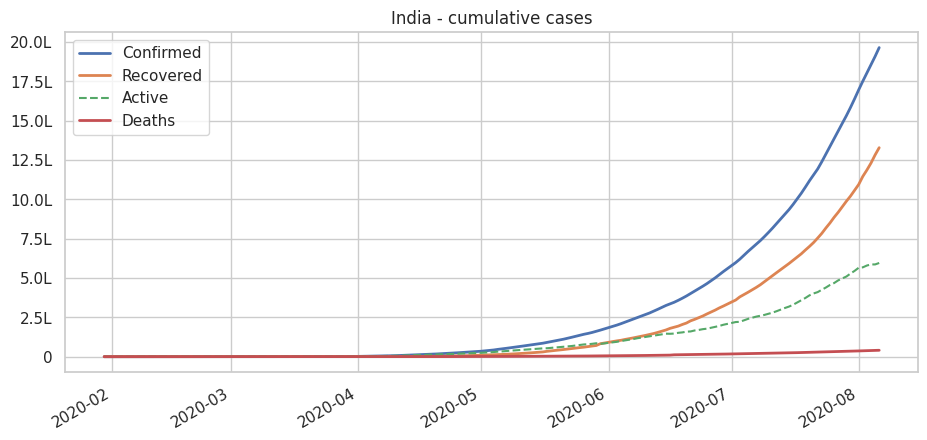

In [12]:
fig, ax = plt.subplots()
ax.plot(india["date"], india["confirmed"], label="Confirmed", linewidth=2)
ax.plot(india["date"], india["recovered"], label="Recovered", linewidth=2)
ax.plot(india["date"], india["active"], label="Active", linestyle="--")
ax.plot(india["date"], india["deaths"], label="Deaths", linewidth=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lakh))
ax.set_title("India - cumulative cases")
ax.legend()
fig.autofmt_xdate()
plt.show()

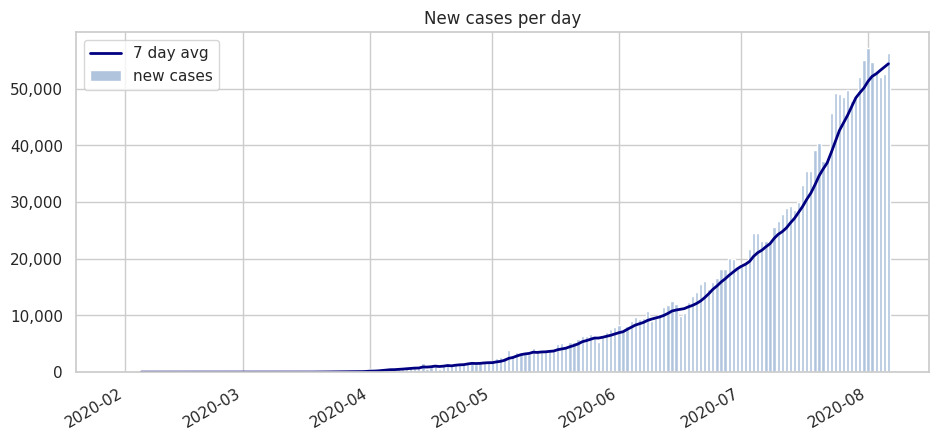

In [13]:
fig, ax = plt.subplots()
ax.bar(india["date"], india["daily_new"], color="lightsteelblue", label="new cases")
ax.plot(india["date"], india["avg_7d"], color="navy", linewidth=2, label="7 day avg")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lakh))
ax.set_title("New cases per day")
ax.legend()
fig.autofmt_xdate()
plt.show()

Basically flat till the end of March, then it keeps climbing. By August it's over 50k new cases a day and still going up, so this dataset stops before the peak (which I know came later, around September).

## State snapshot (last date)

In [14]:
last_day = df["date"].max()
latest = df[df["date"] == last_day].set_index("state")[["confirmed", "recovered", "deaths", "active"]]
latest = latest.sort_values("confirmed", ascending=False)
latest["recovery_rate"] = (latest["recovered"] / latest["confirmed"] * 100).round(1)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)
latest["share"] = (latest["confirmed"] / latest["confirmed"].sum() * 100).round(1)
print(last_day.date(), len(latest), "states")
latest.head(10)

2020-08-06 35 states


,confirmed,recovered,deaths,active,recovery_rate,death_rate,share
state,,,,,,,
Maharashtra,468265,305521,16476,146268,65.2,3.52,23.8
Tamil Nadu,273460,214815,4461,54184,78.6,1.63,13.9
Andhra Pradesh,186461,104354,1681,80426,56.0,0.90,9.5
Karnataka,151449,74679,2804,73966,49.3,1.85,7.7
Delhi,140232,126116,4044,10072,89.9,2.88,7.1
Uttar Pradesh,104388,60558,1857,41973,58.0,1.78,5.3
West Bengal,83800,58962,1846,22992,70.4,2.20,4.3
Telangana,73050,52103,589,20358,71.3,0.81,3.7
Gujarat,66669,49433,2556,14680,74.1,3.83,3.4


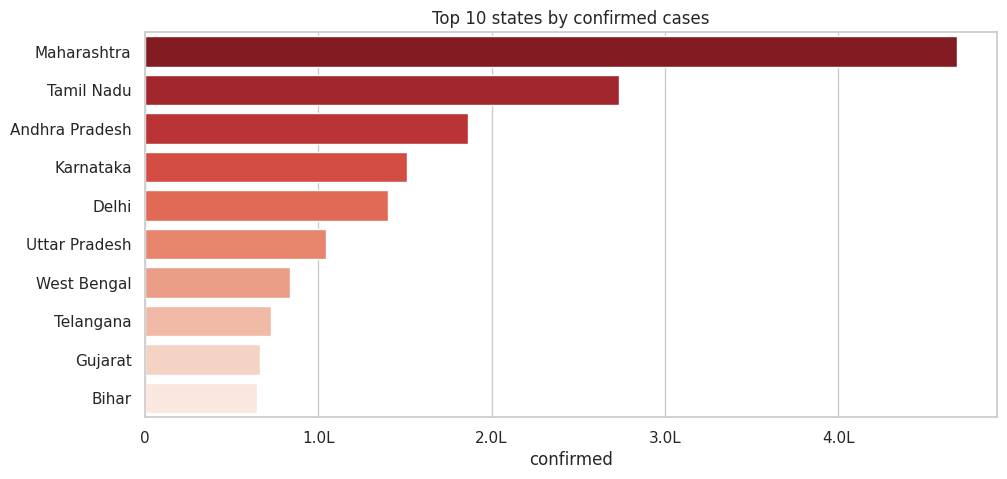

In [15]:
top10 = latest.head(10)
fig, ax = plt.subplots()
sns.barplot(x=top10["confirmed"], y=top10.index, hue=top10.index, palette="Reds_r", legend=False, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lakh))
ax.set_title("Top 10 states by confirmed cases")
ax.set_xlabel("confirmed")
ax.set_ylabel("")
plt.show()

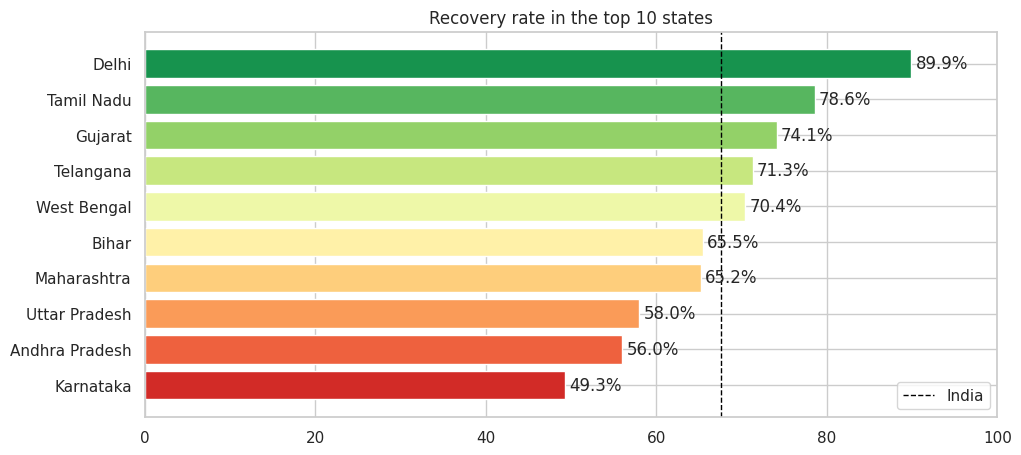

In [16]:
rec = top10.sort_values("recovery_rate")
fig, ax = plt.subplots()
bars = ax.barh(rec.index, rec["recovery_rate"], color=sns.color_palette("RdYlGn", len(rec)))
ax.axvline(india["recovery_rate"].iloc[-1], color="black", linestyle="--", linewidth=1, label="India")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlim(0, 100)
ax.set_title("Recovery rate in the top 10 states")
ax.legend(loc="lower right")
plt.show()

Delhi is way ahead on recovery. Karnataka is the lowest of the big ones, less than half its cases had recovered.

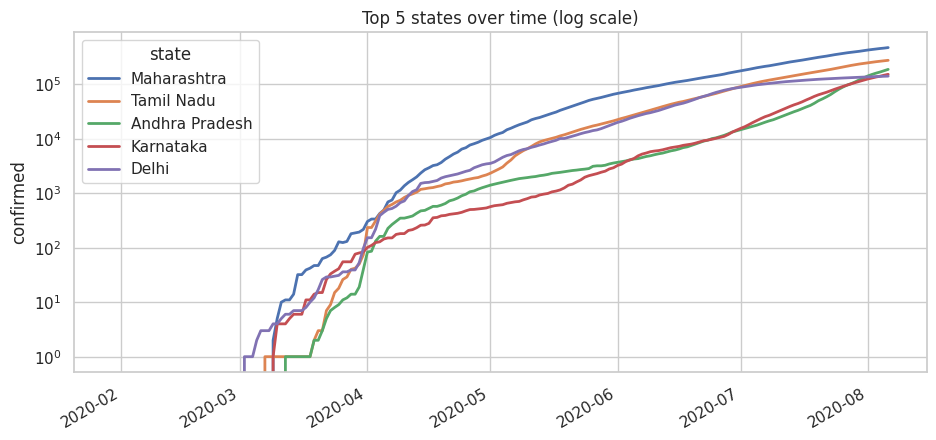

In [17]:
top5 = latest.head(5).index
fig, ax = plt.subplots()
sns.lineplot(data=df[df["state"].isin(top5)], x="date", y="confirmed", hue="state", hue_order=top5, linewidth=2, ax=ax)
ax.set_yscale("log")
ax.set_title("Top 5 states over time (log scale)")
ax.set_xlabel("")
fig.autofmt_xdate()
plt.show()

I used a log scale because otherwise Maharashtra squashes everyone else. You can see Delhi's line flattening out from July.

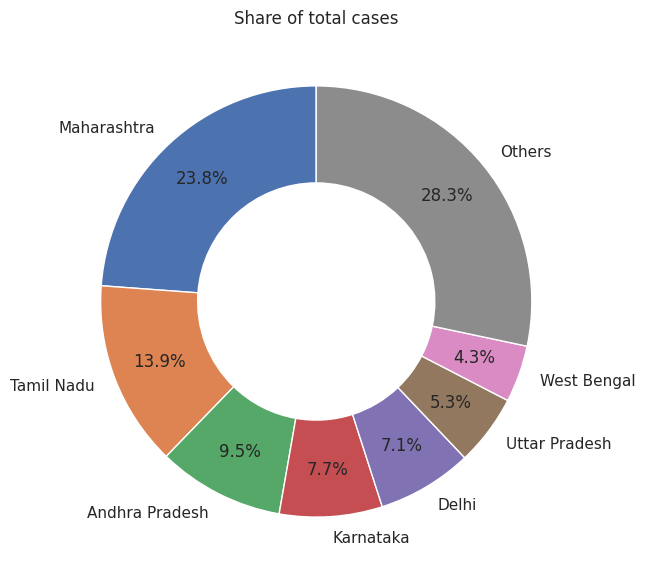

In [18]:
pie_data = latest["confirmed"].head(7).copy()
pie_data["Others"] = latest["confirmed"].iloc[7:].sum()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(pie_data, labels=pie_data.index, autopct="%1.1f%%", startangle=90,
       wedgeprops={"width": 0.45, "edgecolor": "white"}, pctdistance=0.78)
ax.set_title("Share of total cases")
plt.show()

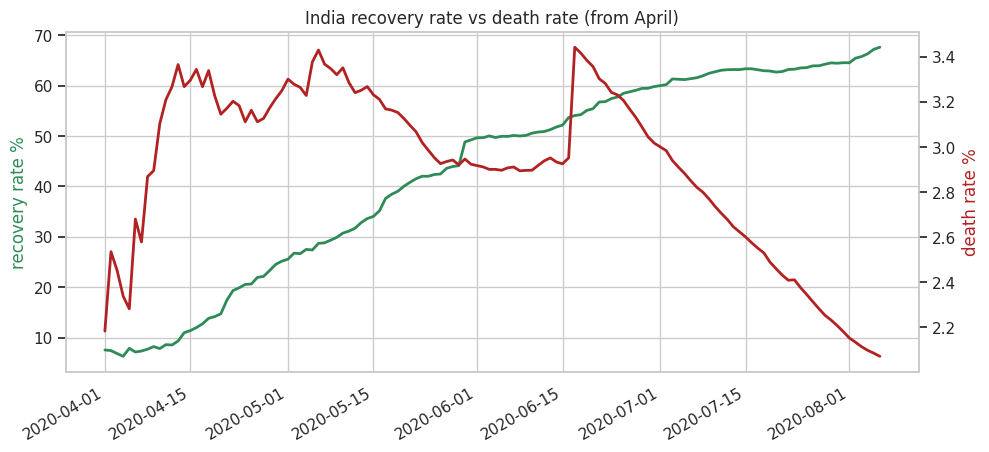

In [19]:
d = india[india["date"] >= "2020-04-01"]
fig, ax1 = plt.subplots()
ax1.plot(d["date"], d["recovery_rate"], color="seagreen", linewidth=2)
ax1.set_ylabel("recovery rate %", color="seagreen")
ax2 = ax1.twinx()
ax2.plot(d["date"], d["death_rate"], color="firebrick", linewidth=2)
ax2.set_ylabel("death rate %", color="firebrick")
ax2.grid(False)
ax1.set_title("India recovery rate vs death rate (from April)")
fig.autofmt_xdate()
plt.show()

Recovery rate goes up the whole time and death rate slowly drops to around 2%. Part of that is probably more testing picking up milder cases.

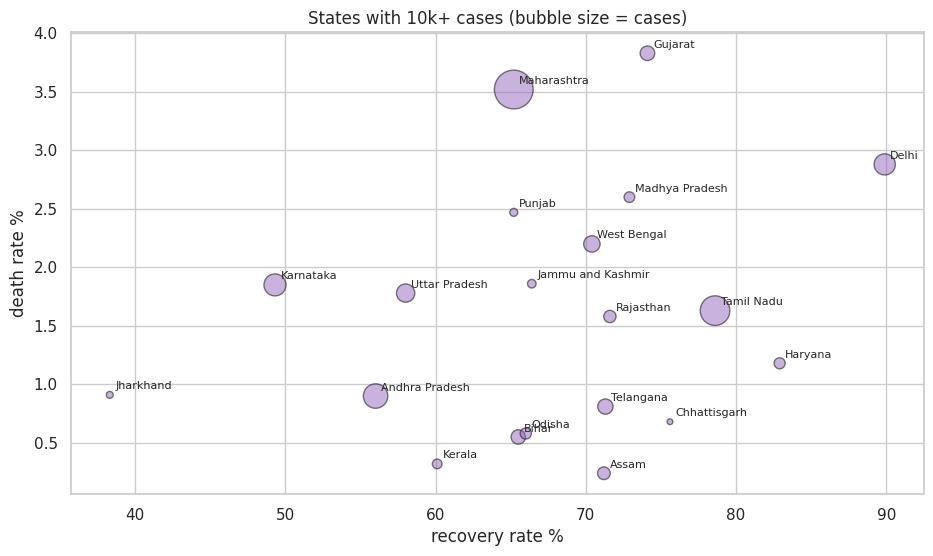

In [20]:
big = latest[latest["confirmed"] >= 10000]
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(big["recovery_rate"], big["death_rate"], s=big["confirmed"] / 600, alpha=0.5, color="tab:purple", edgecolor="black")
for name, row in big.iterrows():
    ax.annotate(name, (row["recovery_rate"], row["death_rate"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("recovery rate %")
ax.set_ylabel("death rate %")
ax.set_title("States with 10k+ cases (bubble size = cases)")
plt.show()

Gujarat and Maharashtra have the highest death rates (both above 3.5%). Andhra Pradesh, Telangana and Bihar are all under 1%, which seems really low, maybe a difference in how deaths were counted.

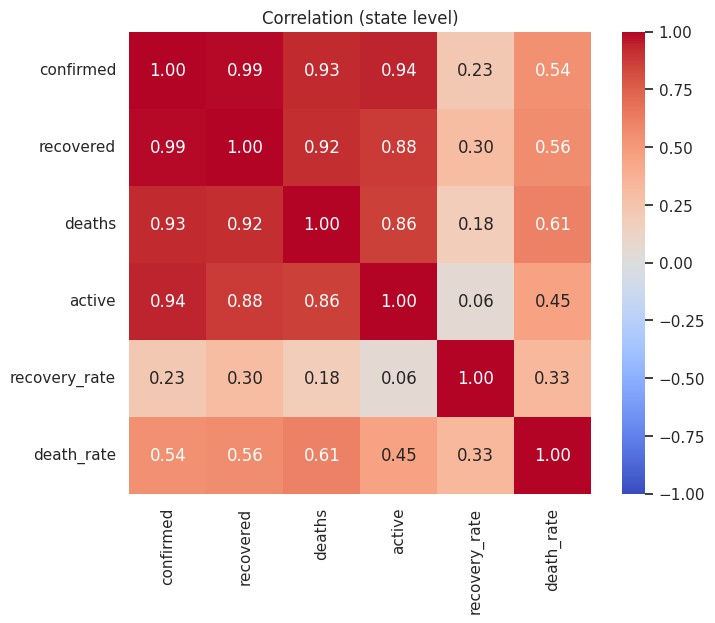

In [21]:
corr = latest[["confirmed", "recovered", "deaths", "active", "recovery_rate", "death_rate"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation (state level)")
plt.show()

All the count columns are almost perfectly correlated, which makes sense since big outbreaks have more of everything. The rates don't really follow size, so they're better for comparing states.

## State x month pivot

In [22]:
monthly = df.pivot_table(index="state", columns="month", values="daily_new", aggfunc="sum", fill_value=0)
monthly = monthly.loc[monthly.sum(axis=1).sort_values(ascending=False).index]
monthly.columns = monthly.columns.astype(str)
monthly.head(10)

month,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,,,
Maharashtra,0.0,0.0,220.0,9699.0,55253.0,104715.0,241915.0,56467.0
Tamil Nadu,0.0,0.0,74.0,2088.0,19022.0,65040.0,153754.0,33482.0
Andhra Pradesh,0.0,0.0,40.0,1292.0,2237.0,10322.0,116666.0,55904.0
Karnataka,0.0,0.0,83.0,452.0,2387.0,11373.0,104337.0,32817.0
Delhi,0.0,0.0,97.0,3342.0,15110.0,66612.0,49242.0,5829.0
Uttar Pradesh,0.0,0.0,101.0,2033.0,5311.0,15383.0,58211.0,23349.0
West Bengal,0.0,0.0,26.0,732.0,4372.0,12777.0,49785.0,16108.0
Telangana,0.0,0.0,79.0,933.0,1487.0,12895.0,45323.0,12333.0
Gujarat,0.0,0.0,73.0,4009.0,12261.0,15595.0,28347.0,6384.0


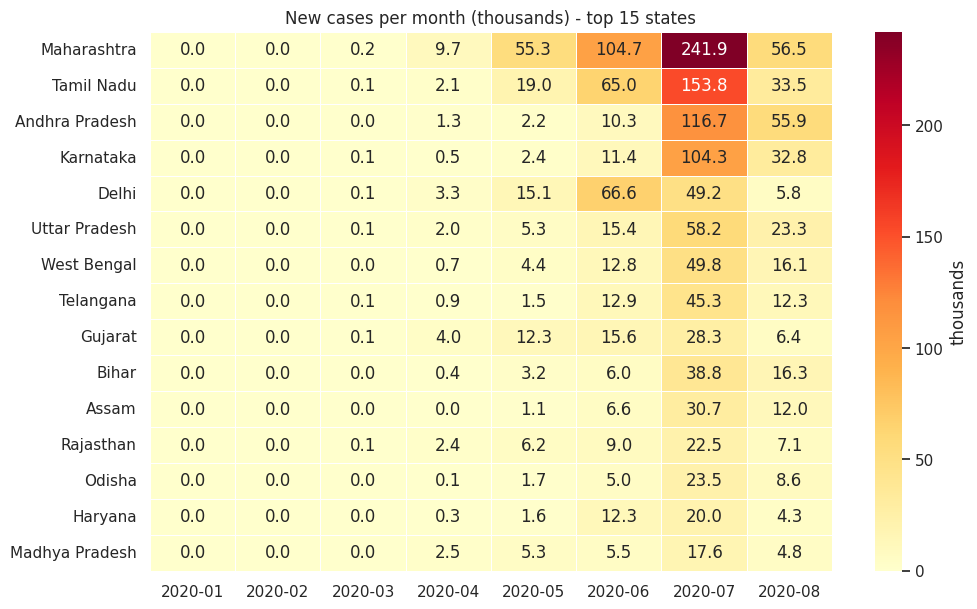

In [23]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(monthly.head(15) / 1000, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.4,
            cbar_kws={"label": "thousands"}, ax=ax)
ax.set_title("New cases per month (thousands) - top 15 states")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

Heads up, August only has 6 days so it looks smaller than it should. July is where almost every state blows up.

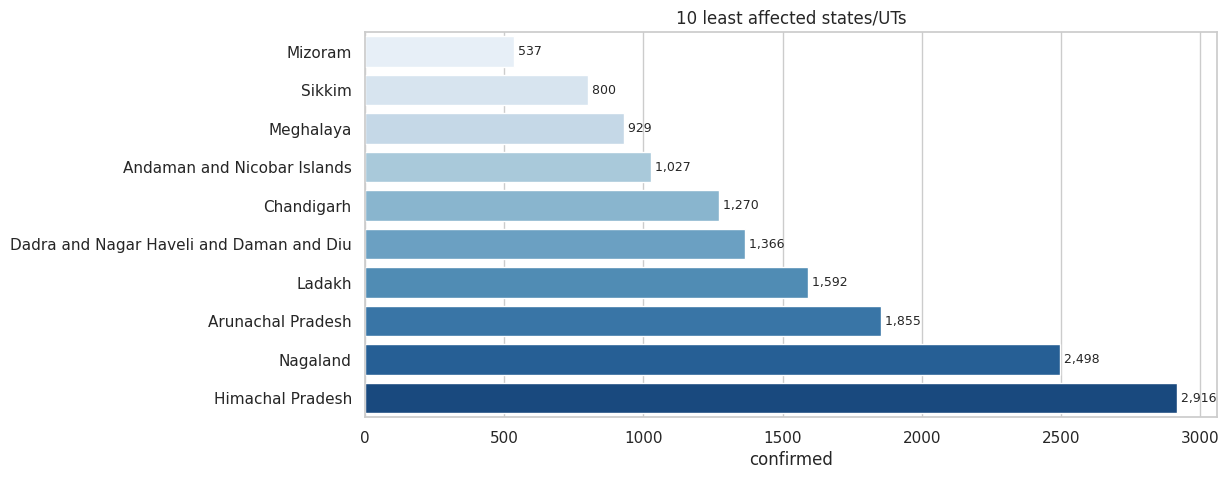

In [24]:
bottom10 = latest.tail(10).sort_values("confirmed")
fig, ax = plt.subplots()
sns.barplot(x=bottom10["confirmed"], y=bottom10.index, hue=bottom10.index, palette="Blues", legend=False, ax=ax)
for i, v in enumerate(bottom10["confirmed"]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_title("10 least affected states/UTs")
ax.set_xlabel("confirmed")
ax.set_ylabel("")
plt.show()

Mostly the northeast states and small UTs. Mizoram had only a few hundred cases by August.

## Vaccinations

The case data ends in Aug 2020 and vaccines start in Jan 2021, so I can't really connect the two. Treating this as its own section.

In [25]:
vacc = vacc_raw[["date", "total_vaccinations", "people_vaccinated", "people_fully_vaccinated"]].copy()
vacc["date"] = pd.to_datetime(vacc["date"])
vacc = vacc.sort_values("date").ffill()
print(vacc["date"].min().date(), "to", vacc["date"].max().date())
vacc.tail()

2021-01-15 to 2024-08-12


,date,total_vaccinations,people_vaccinated,people_fully_vaccinated
1245,2024-08-08,2206867964,1.027439e+09,951990535.0
1246,2024-08-09,2206867970,1.027439e+09,951990537.0
1247,2024-08-10,2206867986,1.027439e+09,951990545.0
1248,2024-08-11,2206867993,1.027439e+09,951990547.0
1249,2024-08-12,2206868000,1.027439e+09,951990552.0


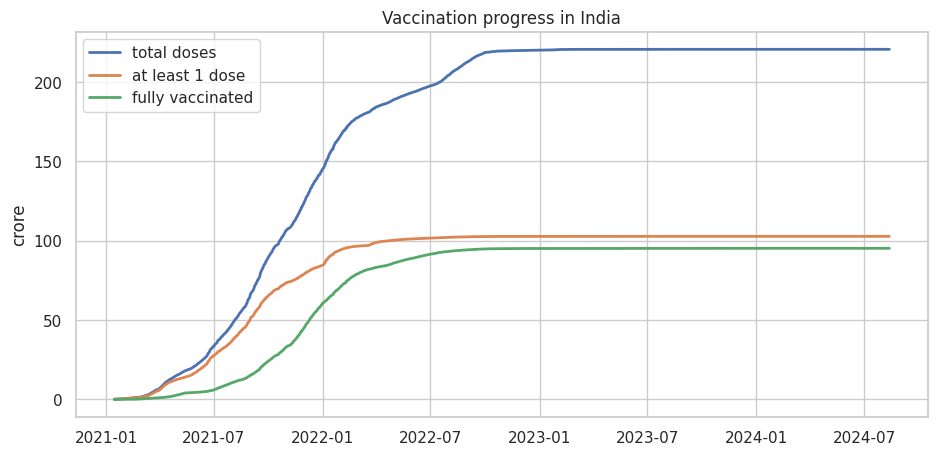

In [26]:
fig, ax = plt.subplots()
ax.plot(vacc["date"], vacc["total_vaccinations"] / 1e7, linewidth=2, label="total doses")
ax.plot(vacc["date"], vacc["people_vaccinated"] / 1e7, linewidth=2, label="at least 1 dose")
ax.plot(vacc["date"], vacc["people_fully_vaccinated"] / 1e7, linewidth=2, label="fully vaccinated")
ax.set_ylabel("crore")
ax.set_title("Vaccination progress in India")
ax.legend()
plt.show()

The steepest part is mid to late 2021. It slows down a lot during 2022 and from 2023 it's basically flat.

## Extra 1: did the lockdown phases show up?

I wanted to check what happened to case growth during each lockdown and unlock phase. Dates are from the government announcements (Wikipedia has the full list).

In [27]:
phases = [
    ("Lockdown 1", "2020-03-25", "2020-04-14"),
    ("Lockdown 2", "2020-04-15", "2020-05-03"),
    ("Lockdown 3", "2020-05-04", "2020-05-17"),
    ("Lockdown 4", "2020-05-18", "2020-05-31"),
    ("Unlock 1", "2020-06-01", "2020-06-30"),
    ("Unlock 2", "2020-07-01", "2020-07-31"),
    ("Unlock 3", "2020-08-01", "2020-08-06"),  # data stops on the 6th
]

rows = []
for name, start, end in phases:
    p = india[(india["date"] >= start) & (india["date"] <= end)]
    first, last = p.iloc[0], p.iloc[-1]
    rows.append({
        "phase": name,
        "days": len(p),
        "cases_at_start": int(first["confirmed"]),
        "cases_at_end": int(last["confirmed"]),
        "avg_new_per_day": round(p["daily_new"].mean()),
        "avg_daily_growth_%": round(p["confirmed"].pct_change().mean() * 100, 2),
    })
phase_table = pd.DataFrame(rows).set_index("phase")
phase_table

,days,cases_at_start,cases_at_end,avg_new_per_day,avg_daily_growth_%
phase,,,,,
Lockdown 1,21,606,10804,490,15.74
Lockdown 2,19,11439,39856,1529,7.20
Lockdown 3,14,42533,90637,3627,6.00
Lockdown 4,14,95759,176652,6144,4.82
Unlock 1,30,184905,559836,12773,3.89
Unlock 2,31,578821,1638870,34808,3.53
Unlock 3,6,1695988,1964536,54278,2.98


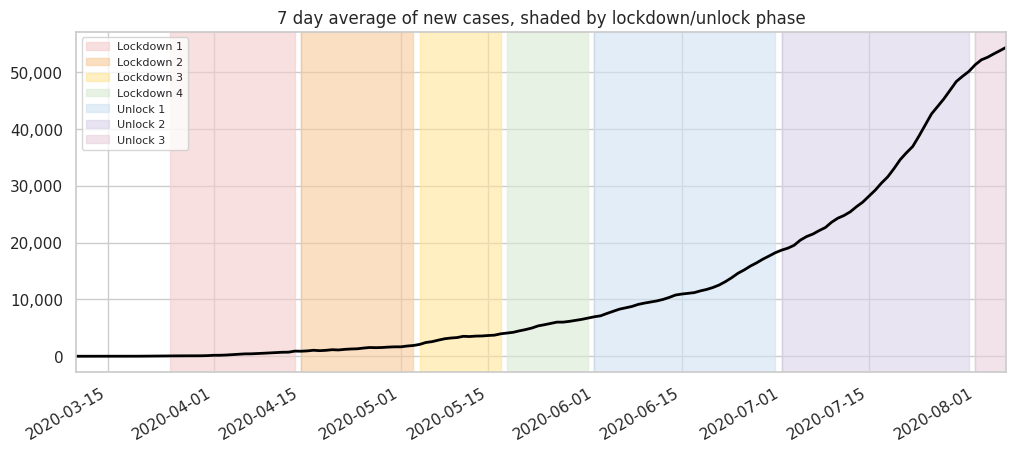

In [28]:
colors = ["#f4cccc", "#f9cb9c", "#ffe599", "#d9ead3", "#cfe2f3", "#d9d2e9", "#ead1dc"]
fig, ax = plt.subplots(figsize=(12, 5))
for (name, start, end), c in zip(phases, colors):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=c, alpha=0.6, label=name)
ax.plot(india["date"], india["avg_7d"], color="black", linewidth=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lakh))
ax.set_xlim(pd.Timestamp("2020-03-10"), india["date"].max())
ax.set_title("7 day average of new cases, shaded by lockdown/unlock phase")
ax.legend(loc="upper left", fontsize=8)
fig.autofmt_xdate()
plt.show()

The daily growth % drops a lot through the lockdowns, from about 16% a day in Lockdown 1 to under 4% by Unlock 2. But the raw number of new cases never went down, it just grew slower. So the lockdown slowed things down but didn't stop the spread, and once things reopened the absolute numbers shot up.

## Extra 2: doubling time

Doubling time = how many days it takes for total cases to double at the current growth rate. Higher is better. I'm using the average growth over the last 7 days to smooth out noisy days.

Formula: doubling time = ln(2) / ln(1 + daily growth rate)

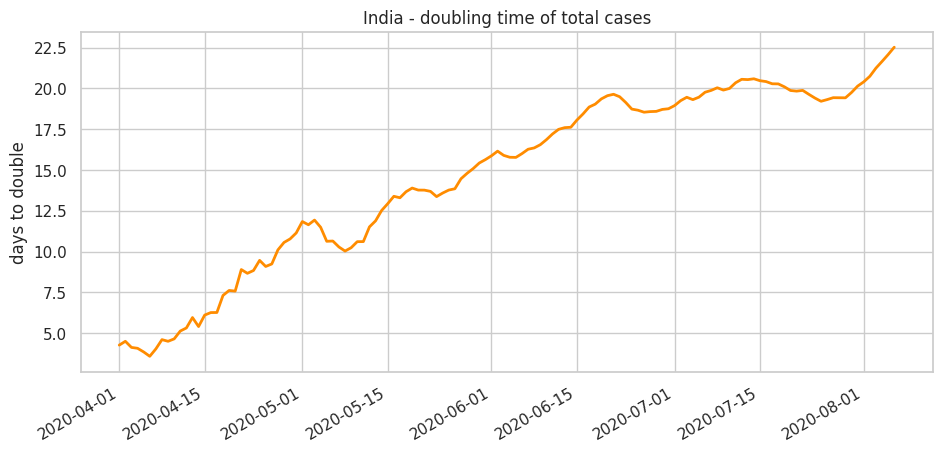

doubling time on 1 Apr: 4.3 days
doubling time on last day: 22.5 days


In [29]:
def doubling_time(series, window=7):
    growth = series.pct_change().rolling(window).mean()
    return np.log(2) / np.log(1 + growth)

india["doubling_days"] = doubling_time(india["confirmed"])

fig, ax = plt.subplots()
d = india[india["date"] >= "2020-04-01"]
ax.plot(d["date"], d["doubling_days"], color="darkorange", linewidth=2)
ax.set_ylabel("days to double")
ax.set_title("India - doubling time of total cases")
fig.autofmt_xdate()
plt.show()

print("doubling time on 1 Apr:", round(india.loc[india["date"] == "2020-04-01", "doubling_days"].iloc[0], 1), "days")
print("doubling time on last day:", round(india["doubling_days"].iloc[-1], 1), "days")

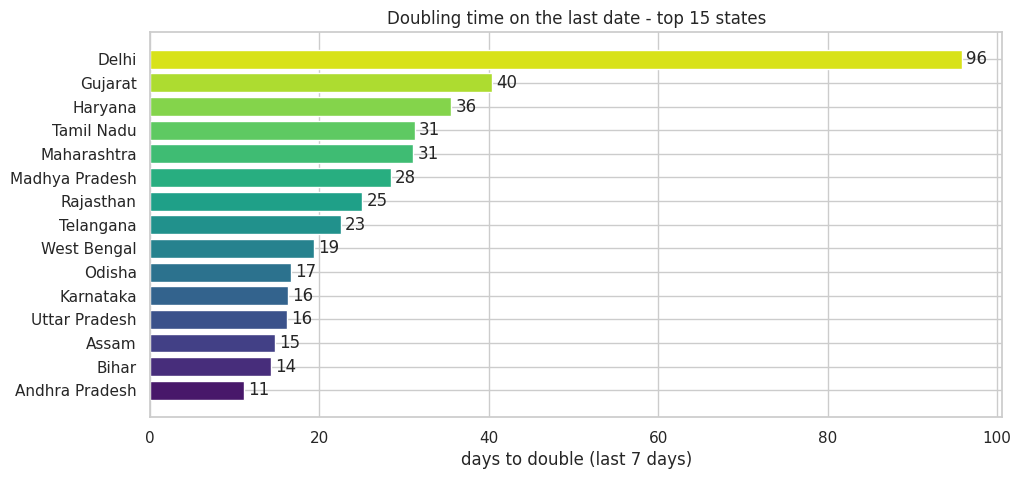

In [30]:
state_dt = {}
for s in latest.head(15).index:
    s_df = df[df["state"] == s].set_index("date")["confirmed"]
    state_dt[s] = doubling_time(s_df).iloc[-1]
state_dt = pd.Series(state_dt).sort_values()

fig, ax = plt.subplots()
bars = ax.barh(state_dt.index, state_dt.values, color=sns.color_palette("viridis", len(state_dt)))
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_xlabel("days to double (last 7 days)")
ax.set_title("Doubling time on the last date - top 15 states")
plt.show()

In early April cases were doubling every 4 or 5 days. By August it's around 3 weeks, so growth slowed down a lot in % terms even though the daily numbers look scary. Andhra Pradesh was growing fastest in August (doubling in about 11 days), then Bihar and Assam. Maharashtra and Tamil Nadu were already down to about a month. Delhi is way off at the other end with a doubling time of over 90 days, its cases were barely growing anymore.

## Extra 3: which states had turned the corner?

Total cases only ever go up, so they don't tell you if things are getting better. Active cases do. If a state's active cases peaked and started falling, it was past its worst point (at least for that wave).

In [31]:
active_summary = []
for s in latest.head(10).index:
    s_df = df[df["state"] == s].set_index("date")["active"]
    peak_day = s_df.idxmax()
    active_summary.append({
        "state": s,
        "peak_active": int(s_df.max()),
        "peak_date": peak_day.date(),
        "active_now": int(s_df.iloc[-1]),
        "now_vs_peak_%": round(s_df.iloc[-1] / s_df.max() * 100, 1),
    })
active_summary = pd.DataFrame(active_summary).set_index("state").sort_values("now_vs_peak_%")
active_summary

,peak_active,peak_date,active_now,now_vs_peak_%
state,,,,
Delhi,28329,2020-06-28,10072,35.6
Tamil Nadu,57968,2020-08-01,54184,93.5
Maharashtra,150966,2020-08-01,146268,96.9
Karnataka,74598,2020-08-03,73966,99.2
Gujarat,14690,2020-08-05,14680,99.9
Andhra Pradesh,80426,2020-08-06,80426,100.0
West Bengal,22992,2020-08-06,22992,100.0
Uttar Pradesh,41973,2020-08-06,41973,100.0
Telangana,20358,2020-08-06,20358,100.0


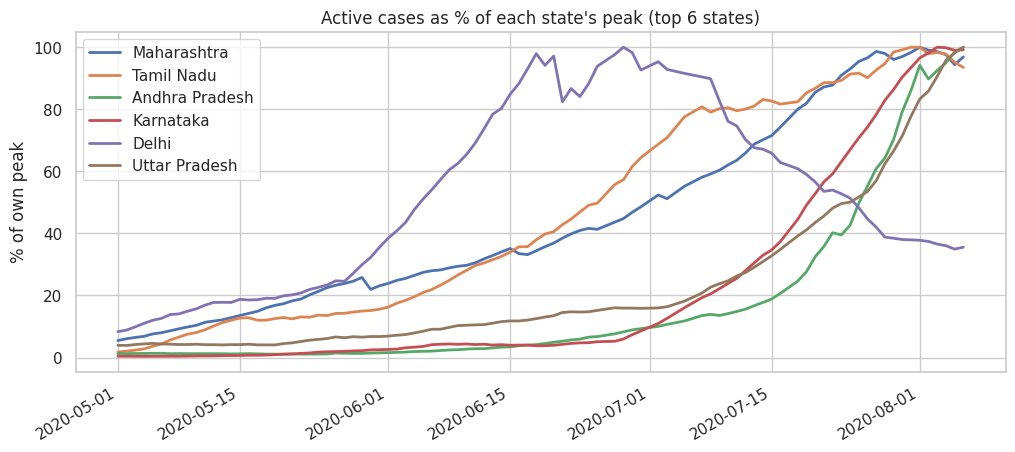

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
for s in latest.head(6).index:
    s_df = df[(df["state"] == s) & (df["date"] >= "2020-05-01")]
    ax.plot(s_df["date"], s_df["active"] / s_df["active"].max() * 100, linewidth=2, label=s)
ax.set_ylabel("% of own peak")
ax.set_title("Active cases as % of each state's peak (top 6 states)")
ax.legend()
fig.autofmt_xdate()
plt.show()

Delhi is the only big state that clearly peaked. Its active cases topped out in late June and were down to about a third of that by August. Tamil Nadu peaked on 1 Aug and was just starting to dip. The rest were still at or near their peak on the last day, so for most of the country the first wave wasn't anywhere near over.

## Saving the cleaned data

In [33]:
out_cols = ["date", "state", "lat", "lon", "confirmed", "recovered", "deaths", "active", "daily_new"]
df[out_cols].to_csv("cleaned_covid_india.csv", index=False)
print("saved", len(df), "rows")

saved 6650 rows


## Quick numbers

In [34]:
end = india.iloc[-1]
peak = india.loc[india["daily_new"].idxmax()]
print(f"Data up to:              {end['date']:%d %b %Y}")
print(f"Total confirmed:         {end['confirmed']:,.0f}")
print(f"Total deaths:            {end['deaths']:,.0f}")
print(f"Recovery rate:           {end['recovery_rate']:.1f}%")
print(f"Death rate:              {end['death_rate']:.2f}%")
print(f"Biggest single day:      {peak['daily_new']:,.0f} ({peak['date']:%d %b})")
print(f"Maharashtra share:       {latest.loc['Maharashtra', 'share']}%")
print(f"Top 5 states share:      {latest['share'].head(5).sum():.1f}%")
print(f"Doubling time at end:    {end['doubling_days']:.1f} days")
print(f"Fully vaccinated:        {vacc['people_fully_vaccinated'].iloc[-1]/1e7:.1f} crore")

Data up to:              06 Aug 2020
Total confirmed:         1,964,536
Total deaths:            40,699
Recovery rate:           67.6%
Death rate:              2.07%
Biggest single day:      57,118 (01 Aug)
Maharashtra share:       23.8%
Top 5 states share:      62.0%
Doubling time at end:    22.5 days
Fully vaccinated:        95.2 crore


## Summary

By 6 August 2020 India had around 19.6 lakh confirmed cases and about 40.7k deaths. Cases were still going up every day when the data ends, so this is only the rising half of the first wave.

Most of the cases were in a few states. Maharashtra alone had about a quarter of them, and the top 5 (Maharashtra, Tamil Nadu, Andhra Pradesh, Karnataka, Delhi) had well over half. At the other end, a lot of the northeast and small UTs had only a few hundred or few thousand cases.

The recovery rate kept improving nationally and ended up around two thirds, while the death rate dropped to around 2%. The difference between states was huge though. Delhi was around 90% recovered, Karnataka was under 50%, and Gujarat had a death rate close to 4%, the worst of the bigger states with Maharashtra right behind.

The lockdowns clearly slowed down the growth rate. Doubling time went from 4 or 5 days in early April to around 3 weeks by August. But new cases per day never actually went down, and once things opened up in June and July the numbers rose really fast.

Looking at active cases, Delhi was the only major state that had clearly passed its peak. Most others were still at their highest point.

The vaccination drive started in Jan 2021 and went past 200 crore doses, but since it doesn't overlap with this case data I couldn't say anything about how it affected cases.

Things to keep in mind:
- the case data stops at 6 Aug 2020 and the source repo isn't updated anymore
- reported cases depend on how much testing each state did, and that varied a lot
- I didn't have population data, so I compared states on rates instead of per-capita numbers
- 4 missing days and 1 stale day were filled in by interpolation, and negative daily jumps (data corrections) were set to 0